# Signal processign tests

## Setup

In [104]:
from scipy import fft, signal
from matplotlib import pyplot as plt
import numpy as np

## FFT common transform pairs

In [105]:
N = 256
start = -10
end = 10
t = np.linspace(start, end, N)
f = fft.rfftfreq(N)

# Inputs

# Impulse
impulseTime = N // 2
x1 = np.zeros(N)
x1[impulseTime] = 1

# Step
riseTime = N // 2
x2 = np.concatenate((np.zeros(riseTime), np.ones(N - riseTime)))

# Sinusoid
x3 = np.sin(t)

# Sinc
simmetryTime = 0  # N // 2 * (end - start) / N
x4 = np.sinc(t - simmetryTime)

# Rectangular pulse
x5 = np.concatenate((np.zeros(N // 3), np.ones(N // 3), np.zeros(N // 3 + 1)))

# Transforms
X1 = fft.rfft(x1)
X2 = fft.rfft(x2)
X3 = fft.rfft(x3)
X4 = fft.rfft(x4)
X5 = fft.rfft(x5)

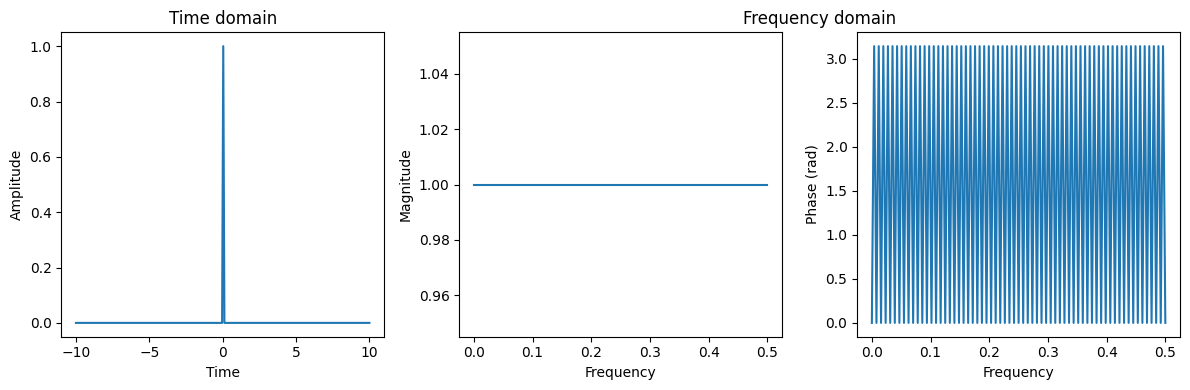

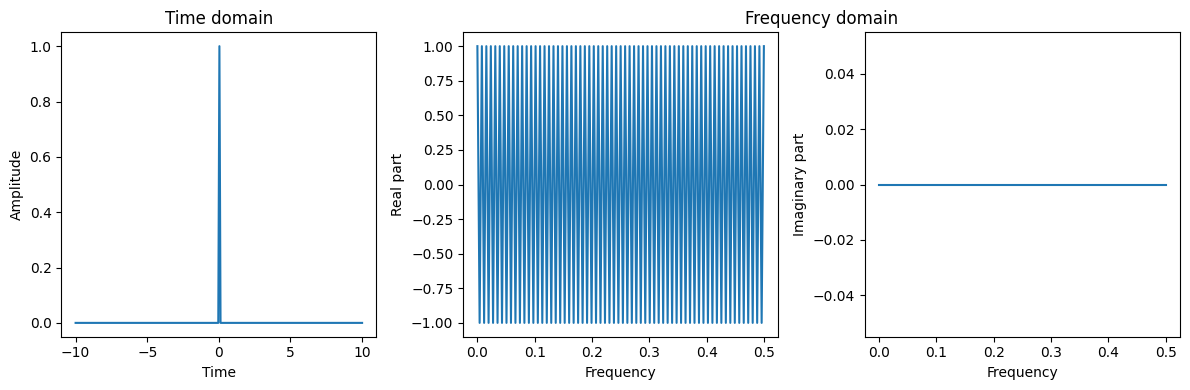

In [ ]:
def plotFTPolar(x, t, X, f):
    XMag = np.abs(X)
    # XPhase = np.unwrap(np.angle(X))
    XPhase = np.angle(X)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].plot(t, x)
    axes[0].set_title("Time domain")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Amplitude")

    axes[1].plot(f, XMag)
    axes[1].set_xlabel("Frequency")
    axes[1].set_ylabel("Magnitude")

    axes[2].plot(f, XPhase)
    axes[2].set_xlabel("Frequency")
    axes[2].set_ylabel("Phase (rad)")

    plt.tight_layout()

    # Draw to compute subplot positions, then place a centered title between the 2nd and 3rd axes
    fig.canvas.draw()
    pos1 = axes[1].get_position()
    pos2 = axes[2].get_position()
    xTitle = (pos1.x0 + pos1.x1 + pos2.x0 + pos2.x1) / 4
    yTitle = max(pos1.y1, pos2.y1) + 0.01
    fig.text(
        xTitle,
        yTitle,
        "Frequency domain",
        ha="center",
        va="bottom",
        fontsize=plt.rcParams["axes.titlesize"],
    )

    plt.show()


def plotFTRect(x, t, X, f):
    XRe = np.real(X)
    XIm = np.imag(X)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].plot(t, x)
    axes[0].set_title("Time domain")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Amplitude")

    axes[1].plot(f, XRe)
    axes[1].set_xlabel("Frequency")
    axes[1].set_ylabel("Real part")

    axes[2].plot(f, XIm)
    axes[2].set_xlabel("Frequency")
    axes[2].set_ylabel("Imaginary part")

    plt.tight_layout()

    # Draw to compute subplot positions, then place a centered title between the 2nd and 3rd axes
    fig.canvas.draw()
    pos1 = axes[1].get_position()
    pos2 = axes[2].get_position()
    xTitle = (pos1.x0 + pos1.x1 + pos2.x0 + pos2.x1) / 4
    yTitle = max(pos1.y1, pos2.y1) + 0.01
    fig.text(
        xTitle,
        yTitle,
        "Frequency domain",
        ha="center",
        va="bottom",
        fontsize=plt.rcParams["axes.titlesize"],
    )

    plt.show()


plotFTPolar(x1, t, X1, f)
plotFTRect(x1, t, X1, f)